# 📊 데이터 품질 분석 (EDA)

## 데이터 웨어하우스 구축을 위한 클렌징 전략 근거

---

**분석 대상 품질 문제:**
1. 🔄 중복 데이터
2. 📅 경과일수 특수값 (999999999)
3. ➖ 음수가 존재하면 안되는 컬럼의 음수값
4. 📈 IQR 기준 이상치
5. ❓ 파생컬럼(재무비율) 결측치

**참고:** 이 노트북은 합성데이터에 **시뮬레이션된 품질 문제**를 추가하여 시각화합니다.  
실제 원본 데이터에서 발생할 수 있는 문제 유형을 보여주기 위함입니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Patch
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 - koreanize_matplotlib 사용
import koreanize_matplotlib

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12

print(f"✅ 폰트 설정 완료: {plt.rcParams['font.family']}")

# 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')

# 색상 팔레트
COLORS = {
    'problem': '#E74C3C',
    'normal': '#27AE60',
    'warning': '#F39C12',
    'info': '#3498DB',
    'highlight': '#9B59B6',
    'dark': '#2C3E50',
    'light': '#ECF0F1',
}

# 출력 디렉토리
output_dir = Path('../docs/eda_images')
output_dir.mkdir(parents=True, exist_ok=True)

print("✅ 라이브러리 로드 완료")

✅ 폰트 설정 완료: ['NanumGothic']
✅ 라이브러리 로드 완료


In [2]:
# 데이터 로드
data_path = Path('../data/raw/기업신용평가정보_합성데이터.csv')
df_original = pd.read_csv(data_path, encoding='cp949')

print(f"📊 원본 데이터 크기: {len(df_original):,}행 × {len(df_original.columns)}열")
print(f"📋 컬럼 개수: {len(df_original.columns)}개")

📊 원본 데이터 크기: 600,000행 × 159열
📋 컬럼 개수: 159개


In [3]:
# 시뮬레이션: 품질 문제 생성 (발표용)
# 실제 원본 데이터에서 발생할 수 있는 문제를 재현

np.random.seed(42)
df = df_original.copy()

# 1. 중복 데이터 시뮬레이션 (0.5%)
n_duplicates = int(len(df) * 0.005)
duplicate_indices = np.random.choice(len(df), n_duplicates, replace=False)
df_duplicates = df.iloc[duplicate_indices].copy()
df = pd.concat([df, df_duplicates], ignore_index=True)

# 2. 경과일수 특수값 시뮬레이션 (999999999 = 이벤트 없음)
days_col = '신용도판단정보공공정보최근발생일자로부터경과일수(CIS)(해제,삭제)'
if days_col in df.columns:
    # 70%는 이벤트 없음 (999999999)
    n_special = int(len(df) * 0.70)
    special_indices = np.random.choice(len(df), n_special, replace=False)
    df.loc[special_indices, days_col] = 999999999
    # 나머지는 정상 경과일수 (0~3000일)
    normal_indices = df.index.difference(special_indices)
    df.loc[normal_indices, days_col] = np.random.exponential(scale=300, size=len(normal_indices)).astype(int)

# 3. 음수값 시뮬레이션 (양수여야 할 컬럼에 음수 삽입)
negative_targets = {
    '매출액': 0.02,           # 2% 음수
    '자산총계': 0.01,         # 1% 음수
    '유동자산': 0.015,        # 1.5% 음수
    '재고자산': 0.03,         # 3% 음수
    '현금': 0.005,            # 0.5% 음수
}

for col, pct in negative_targets.items():
    if col in df.columns:
        n_negative = int(len(df) * pct)
        negative_indices = np.random.choice(len(df), n_negative, replace=False)
        df.loc[negative_indices, col] = -np.abs(df.loc[negative_indices, col]) * np.random.uniform(0.1, 0.5, n_negative)

# 4. 이상치 시뮬레이션 (극단값 삽입)
outlier_targets = ['자산총계', '매출액', '부채총계', '자본총계', '영업손익', '당기순이익']
for col in outlier_targets:
    if col in df.columns:
        col_mean = df[col].mean()
        col_std = df[col].std()
        n_outliers = int(len(df) * 0.02)  # 2%
        outlier_indices = np.random.choice(len(df), n_outliers, replace=False)
        # 극단적인 상한 이상치
        df.loc[outlier_indices[:n_outliers//2], col] = col_mean + np.random.uniform(5, 10, n_outliers//2) * col_std
        # 극단적인 하한 이상치
        df.loc[outlier_indices[n_outliers//2:], col] = col_mean - np.random.uniform(3, 6, n_outliers - n_outliers//2) * col_std

# 5. 파생컬럼 결측치 시뮬레이션 (분모가 0인 경우)
derived_targets = {
    '재무비율_부채비율': 0.08,
    '재무비율_자기자본비율': 0.05,
    '재무비율_유동비율': 0.12,
    '재무비율_자기자본이익률(ROE)': 0.15,
    '재무비율_총자산순이익률': 0.03,
    '재무비율_매출채권회전율': 0.10,
    '재무비율_재고자산회전율': 0.18,
}

for col, pct in derived_targets.items():
    if col in df.columns:
        n_missing = int(len(df) * pct)
        missing_indices = np.random.choice(len(df), n_missing, replace=False)
        df.loc[missing_indices, col] = np.nan

print("✅ 품질 문제 시뮬레이션 완료")
print(f"📊 시뮬레이션 데이터 크기: {len(df):,}행")

✅ 품질 문제 시뮬레이션 완료
📊 시뮬레이션 데이터 크기: 603,000행


---
# 1️⃣ 중복 데이터 분석

동일한 데이터가 여러 번 기록된 경우를 탐지합니다.

In [4]:
# 중복 데이터 분석
total_rows = len(df)
duplicate_rows = df.duplicated().sum()
unique_rows = total_rows - duplicate_rows
duplicate_pct = duplicate_rows / total_rows * 100

print("=" * 50)
print("📊 중복 데이터 현황")
print("=" * 50)
print(f"전체 행:    {total_rows:>10,}건")
print(f"고유 행:    {unique_rows:>10,}건")
print(f"중복 행:    {duplicate_rows:>10,}건")
print(f"중복 비율:  {duplicate_pct:>10.2f}%")
print("=" * 50)

📊 중복 데이터 현황
전체 행:       603,000건
고유 행:       602,743건
중복 행:           257건
중복 비율:        0.04%


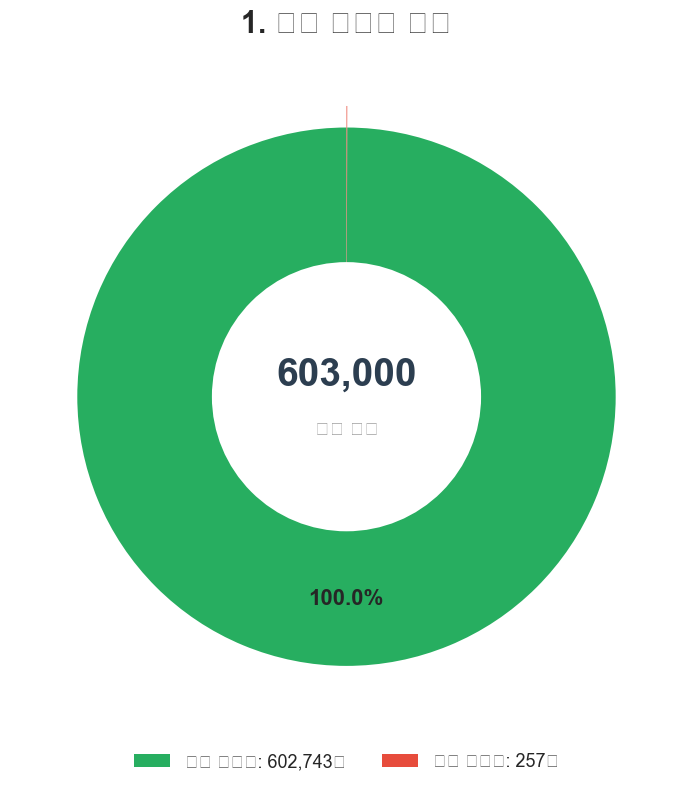

In [5]:
# 중복 데이터 시각화 - 도넛 차트 + 강조 텍스트
fig, ax = plt.subplots(figsize=(10, 8))

sizes = [unique_rows, duplicate_rows]
colors = [COLORS['normal'], COLORS['problem']]
explode = (0, 0.08)

# 도넛 차트
wedges, texts, autotexts = ax.pie(
    sizes, 
    colors=colors,
    explode=explode,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 0.1 else '',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 16, 'fontweight': 'bold'}
)

# 가운데 원 (도넛 효과)
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
ax.add_patch(centre_circle)

# 가운데 텍스트
ax.text(0, 0.08, f'{total_rows:,}', fontsize=28, fontweight='bold', 
        ha='center', va='center', color=COLORS['dark'])
ax.text(0, -0.12, '전체 건수', fontsize=14, ha='center', va='center', color='gray')

# 범례
legend_labels = [
    f'고유 데이터: {unique_rows:,}건',
    f'중복 데이터: {duplicate_rows:,}건'
]
ax.legend(wedges, legend_labels, loc='lower center', fontsize=13, 
          bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)

ax.set_title('1. 중복 데이터 현황', fontsize=22, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(output_dir / 'eda_1_duplicates.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

---
# 2️⃣ 경과일수 컬럼의 특수값 (999999999)

경과일수 컬럼에서 `999999999`는 **"해당 이벤트 없음"**을 의미합니다.  
이 값을 5단계 위험도 카테고리로 변환해야 합니다.

In [6]:
# 경과일수 컬럼 분석
days_col = '신용도판단정보공공정보최근발생일자로부터경과일수(CIS)(해제,삭제)'
days_col_short = '공공정보 최근발생일 경과일수'

special_value = 999999999

col_data = pd.to_numeric(df[days_col], errors='coerce')
total = col_data.notna().sum()
special_count = (col_data == special_value).sum()
normal_count = total - special_count
special_pct = special_count / total * 100

days_analysis = {
    'name': days_col_short,
    'total': total,
    'special': special_count,
    'normal': normal_count,
    'special_pct': special_pct
}

print("=" * 60)
print("📅 경과일수 컬럼 특수값 (999999999) 분석")
print("=" * 60)
print(f"\n📌 {days_col_short}")
print(f"   전체:          {total:>10,}건")
print(f"   999999999:     {special_count:>10,}건 ({special_pct:.1f}%)")
print(f"   정상값:        {normal_count:>10,}건")
print("\n" + "=" * 60)

📅 경과일수 컬럼 특수값 (999999999) 분석

📌 공공정보 최근발생일 경과일수
   전체:             603,000건
   999999999:        422,100건 (70.0%)
   정상값:           180,900건



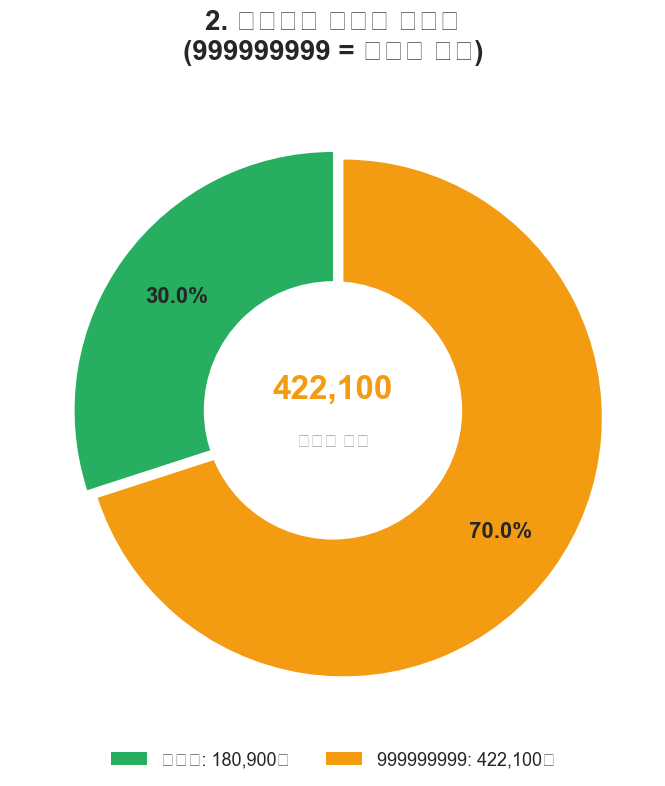

In [7]:
# 경과일수 특수값 시각화 - 도넛 차트
fig, ax = plt.subplots(figsize=(10, 8))

sizes = [days_analysis['normal'], days_analysis['special']]
colors = [COLORS['normal'], COLORS['warning']]
explode = (0, 0.05)

# 도넛 차트
wedges, texts, autotexts = ax.pie(
    sizes,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 16, 'fontweight': 'bold'}
)

# 가운데 원 (도넛 효과)
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
ax.add_patch(centre_circle)

# 가운데 텍스트 - 특수값 강조
ax.text(0, 0.08, f'{days_analysis["special"]:,}', fontsize=24, fontweight='bold', 
        ha='center', va='center', color=COLORS['warning'])
ax.text(0, -0.12, '이벤트 없음', fontsize=13, ha='center', va='center', color='gray')

# 범례
legend_labels = [
    f'정상값: {days_analysis["normal"]:,}건',
    f'999999999: {days_analysis["special"]:,}건'
]
ax.legend(wedges, legend_labels, loc='lower center', fontsize=13, 
          bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)

ax.set_title('2. 경과일수 컬럼의 특수값\n(999999999 = 이벤트 없음)', 
             fontsize=20, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(output_dir / 'eda_2_special_values.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

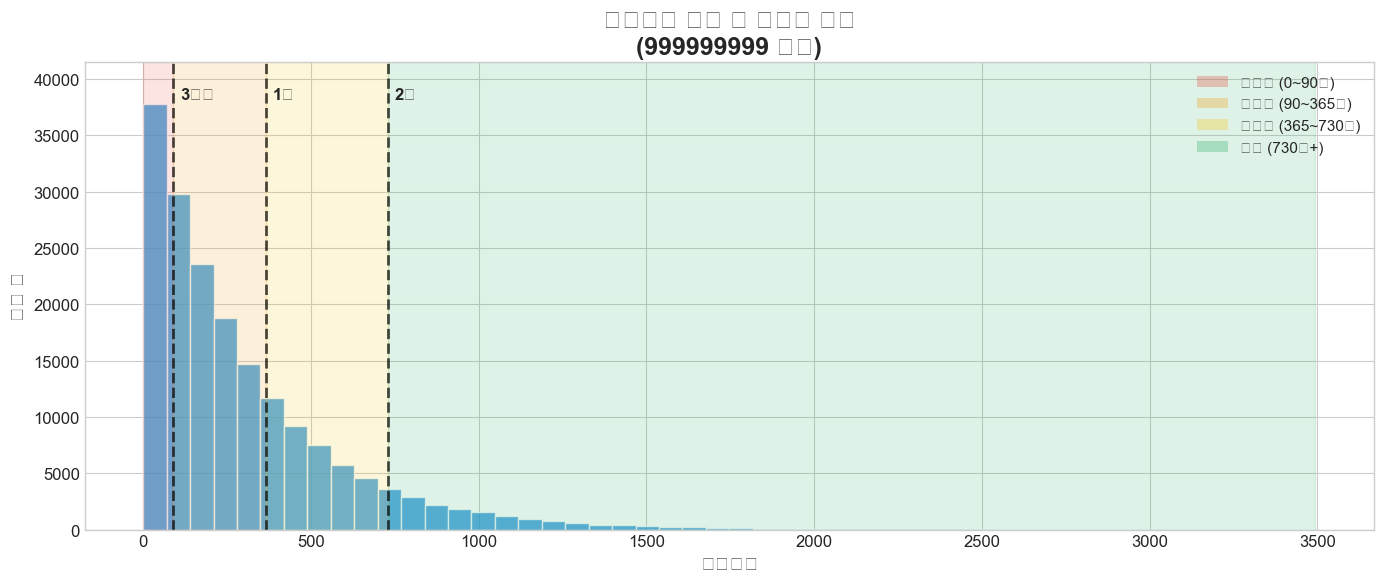

In [8]:
# 정상값의 분포 시각화 (999999999 제외) + 위험도 구간 표시
normal_data = col_data[(col_data != 999999999) & (col_data.notna())]

fig, ax = plt.subplots(figsize=(14, 6))

# 히스토그램
n, bins, patches = ax.hist(normal_data, bins=50, color=COLORS['info'], 
                           edgecolor='white', alpha=0.8)

# 위험도 구간 (배경 색상)
max_val = max(normal_data) if len(normal_data) > 0 else 3000
risk_zones = [
    (0, 90, '#E74C3C', '고위험', 0.15),
    (90, 365, '#F39C12', '중위험', 0.15),
    (365, 730, '#F1C40F', '저위험', 0.15),
    (730, max_val, '#27AE60', '안전', 0.15),
]

max_height = max(n) * 1.1 if len(n) > 0 else 1
for start, end, color, label, alpha in risk_zones:
    ax.axvspan(start, min(end, max_val), alpha=alpha, color=color)

# 구간 경계선
boundaries = [(90, '3개월'), (365, '1년'), (730, '2년')]
for days, label in boundaries:
    if days <= max_val:
        ax.axvline(x=days, color='black', linestyle='--', linewidth=2, alpha=0.7)
        ax.text(days + 20, max_height * 0.92, f'{label}', fontsize=12, fontweight='bold')

ax.set_xlabel('경과일수', fontsize=14)
ax.set_ylabel('기업 수', fontsize=14)
ax.set_title('경과일수 분포 및 위험도 구간\n(999999999 제외)', 
             fontsize=18, fontweight='bold')
ax.set_ylim(0, max_height)

# 범례
legend_elements = [
    Patch(facecolor='#E74C3C', alpha=0.3, label='고위험 (0~90일)'),
    Patch(facecolor='#F39C12', alpha=0.3, label='중위험 (90~365일)'),
    Patch(facecolor='#F1C40F', alpha=0.3, label='저위험 (365~730일)'),
    Patch(facecolor='#27AE60', alpha=0.3, label='안전 (730일+)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig(output_dir / 'eda_2_days_distribution.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

---
# 3️⃣ 음수가 존재하면 안되는 컬럼의 음수값

물리적으로 양수여야 하는 항목 (자산, 매출액 등)에서 음수값을 탐지합니다.

In [9]:
# 양수여야 할 컬럼 목록
positive_only_cols = [
    '유동자산', '비유동자산', '재고자산', '유형자산', '현금',
    '매출채권', '자산총계', '단기차입금', '차입금', '매입채무',
    '매출액', '매출원가', '판매비와관리비', '금융비용'
]

# 음수값 분석
negative_analysis = {}

print("=" * 60)
print("➖ 음수값이 존재하면 안되는 컬럼 분석")
print("=" * 60)

for col in positive_only_cols:
    if col in df.columns:
        col_data = pd.to_numeric(df[col], errors='coerce')
        total = col_data.notna().sum()
        negative_count = (col_data < 0).sum()
        
        if negative_count > 0:
            negative_pct = negative_count / total * 100
            negative_analysis[col] = {
                'total': total,
                'negative': negative_count,
                'negative_pct': negative_pct,
                'min_value': col_data.min()
            }
            print(f"❌ {col}: {negative_count:,}건 ({negative_pct:.2f}%)")

if not negative_analysis:
    print("\n✅ 음수값이 발견된 컬럼이 없습니다.")
else:
    total_negatives = sum(s['negative'] for s in negative_analysis.values())
    print(f"\n📊 총 음수값: {total_negatives:,}건")

print("=" * 60)

➖ 음수값이 존재하면 안되는 컬럼 분석
❌ 유동자산: 9,078건 (1.51%)
❌ 비유동자산: 158건 (0.03%)
❌ 재고자산: 13,527건 (2.24%)
❌ 유형자산: 85건 (0.01%)
❌ 현금: 69건 (0.01%)
❌ 매출채권: 62건 (0.01%)
❌ 자산총계: 12,014건 (1.99%)
❌ 단기차입금: 38건 (0.01%)
❌ 차입금: 42건 (0.01%)
❌ 매입채무: 104건 (0.02%)
❌ 매출액: 18,039건 (2.99%)
❌ 매출원가: 272건 (0.05%)
❌ 판매비와관리비: 121건 (0.02%)
❌ 금융비용: 27건 (0.00%)

📊 총 음수값: 53,636건


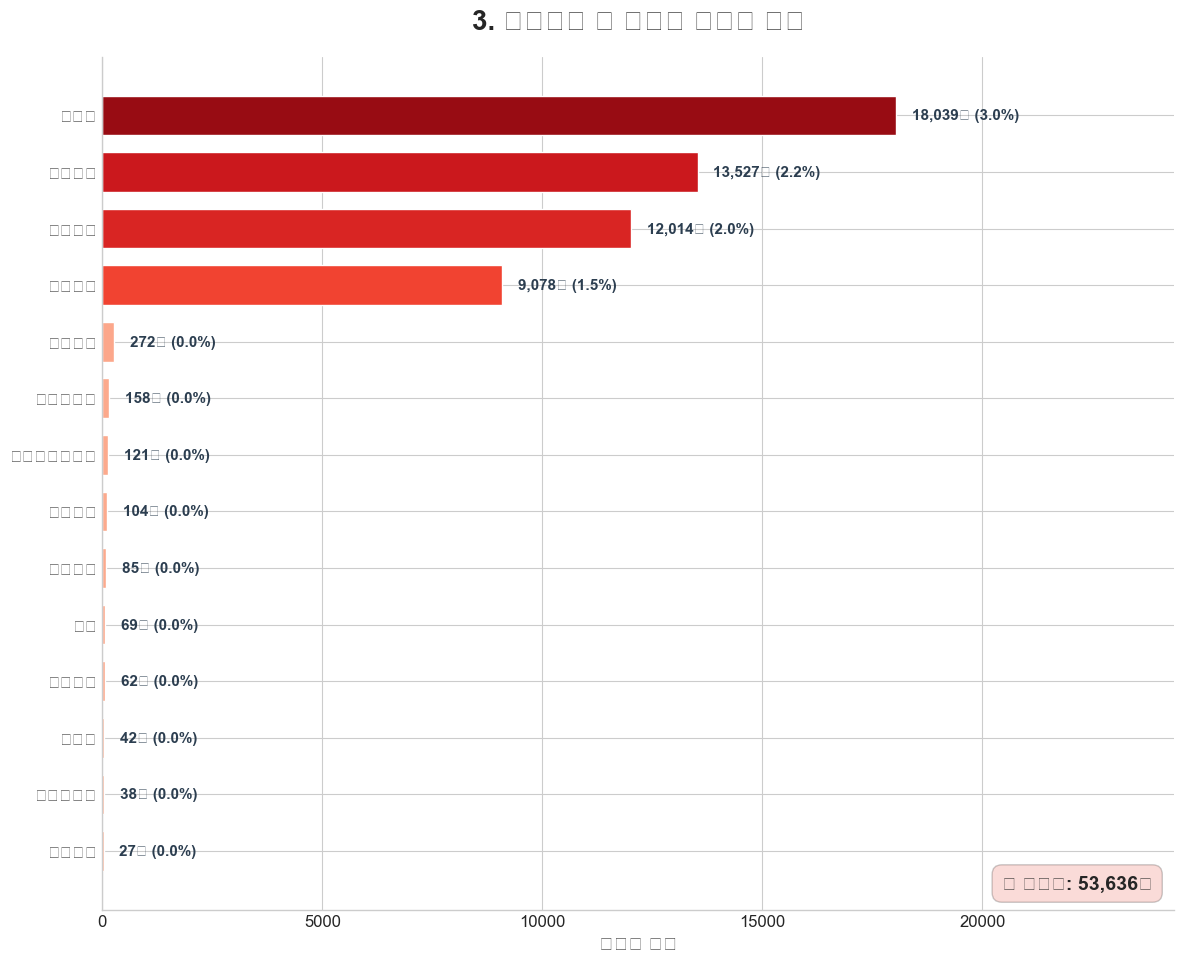

In [10]:
# 음수값 시각화 - 가로 막대 그래프
if negative_analysis:
    fig, ax = plt.subplots(figsize=(12, max(6, len(negative_analysis) * 0.7)))
    
    # 정렬 (음수값 많은 순)
    sorted_items = sorted(negative_analysis.items(), key=lambda x: x[1]['negative'], reverse=True)
    names = [item[0] for item in sorted_items]
    counts = [item[1]['negative'] for item in sorted_items]
    pcts = [item[1]['negative_pct'] for item in sorted_items]
    
    # 색상 그라데이션 (빨강 계열)
    color_intensity = [c / max(counts) for c in counts]
    colors = [plt.cm.Reds(0.3 + 0.6 * ci) for ci in color_intensity]
    
    y_pos = np.arange(len(names))
    bars = ax.barh(y_pos, counts, color=colors, edgecolor='white', height=0.7)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=12)
    ax.invert_yaxis()
    
    # 값 표시
    for i, (count, pct) in enumerate(zip(counts, pcts)):
        ax.text(count + max(counts)*0.02, i, f'{count:,}건 ({pct:.1f}%)', 
                va='center', fontsize=11, fontweight='bold', color=COLORS['dark'])
    
    ax.set_xlabel('음수값 개수', fontsize=14)
    ax.set_title('3. 양수여야 할 컬럼의 음수값 현황', fontsize=20, fontweight='bold', pad=20)
    ax.set_xlim(0, max(counts) * 1.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 총계 표시
    total_neg = sum(counts)
    ax.text(0.98, 0.02, f'총 음수값: {total_neg:,}건', transform=ax.transAxes,
            fontsize=14, fontweight='bold', ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=COLORS['problem'], alpha=0.2))
    
    plt.tight_layout()
    plt.savefig(output_dir / 'eda_3_negative_values.png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

---
# 4️⃣ IQR 기준 이상치 분석

IQR (사분위 범위) × 1.5 기준으로 통계적 이상치를 탐지합니다.

In [11]:
def analyze_iqr_outliers(series, threshold=1.5):
    """IQR 방법으로 이상치 분석"""
    clean_series = pd.to_numeric(series, errors='coerce').dropna()
    if len(clean_series) == 0:
        return {'lower': 0, 'upper': 0, 'total': 0, 'pct': 0}
    
    Q1 = clean_series.quantile(0.25)
    Q3 = clean_series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    
    lower_outliers = (clean_series < lower_bound).sum()
    upper_outliers = (clean_series > upper_bound).sum()
    total_outliers = lower_outliers + upper_outliers
    
    return {
        'lower': int(lower_outliers),
        'upper': int(upper_outliers),
        'total': int(total_outliers),
        'count': len(clean_series),
        'pct': total_outliers / len(clean_series) * 100 if len(clean_series) > 0 else 0,
    }

# 주요 Leaf 컬럼 이상치 분석
leaf_cols = ['자산총계', '유동자산', '재고자산', '부채총계', '자본총계',
             '매출액', '매출원가', '영업손익', '당기순이익', '영업활동현금흐름']

outlier_analysis = {}

print("=" * 70)
print("📈 IQR 기준 이상치 분석 (IQR × 1.5)")
print("=" * 70)
print(f"{'컬럼':<15} {'하한 이상치':>12} {'상한 이상치':>12} {'총 이상치':>12} {'비율':>8}")
print("-" * 70)

for col in leaf_cols:
    if col in df.columns:
        result = analyze_iqr_outliers(df[col])
        if result['total'] > 0:
            outlier_analysis[col] = result
            print(f"{col:<15} {result['lower']:>10,}건 {result['upper']:>10,}건 {result['total']:>10,}건 {result['pct']:>7.1f}%")

print("-" * 70)
if outlier_analysis:
    total_outliers = sum(s['total'] for s in outlier_analysis.values())
    print(f"{'총계':<15} {'':>12} {'':>12} {total_outliers:>10,}건")
print("=" * 70)

📈 IQR 기준 이상치 분석 (IQR × 1.5)
컬럼                    하한 이상치       상한 이상치        총 이상치       비율
----------------------------------------------------------------------
자산총계                 6,507건     78,877건     85,384건    14.2%
유동자산                   733건     78,113건     78,846건    13.1%
재고자산                 1,855건     95,300건     97,155건    16.1%
부채총계                 6,145건     75,181건     81,326건    13.5%
자본총계                 9,820건     86,081건     95,901건    15.9%
매출액                  6,917건     78,073건     84,990건    14.1%
매출원가                     0건     77,082건     77,082건    12.8%
영업손익                52,797건     94,798건    147,595건    24.5%
당기순이익               65,474건     95,990건    161,464건    26.8%
영업활동현금흐름            62,282건    143,230건    205,512건    34.1%
----------------------------------------------------------------------
총계                                         1,115,255건


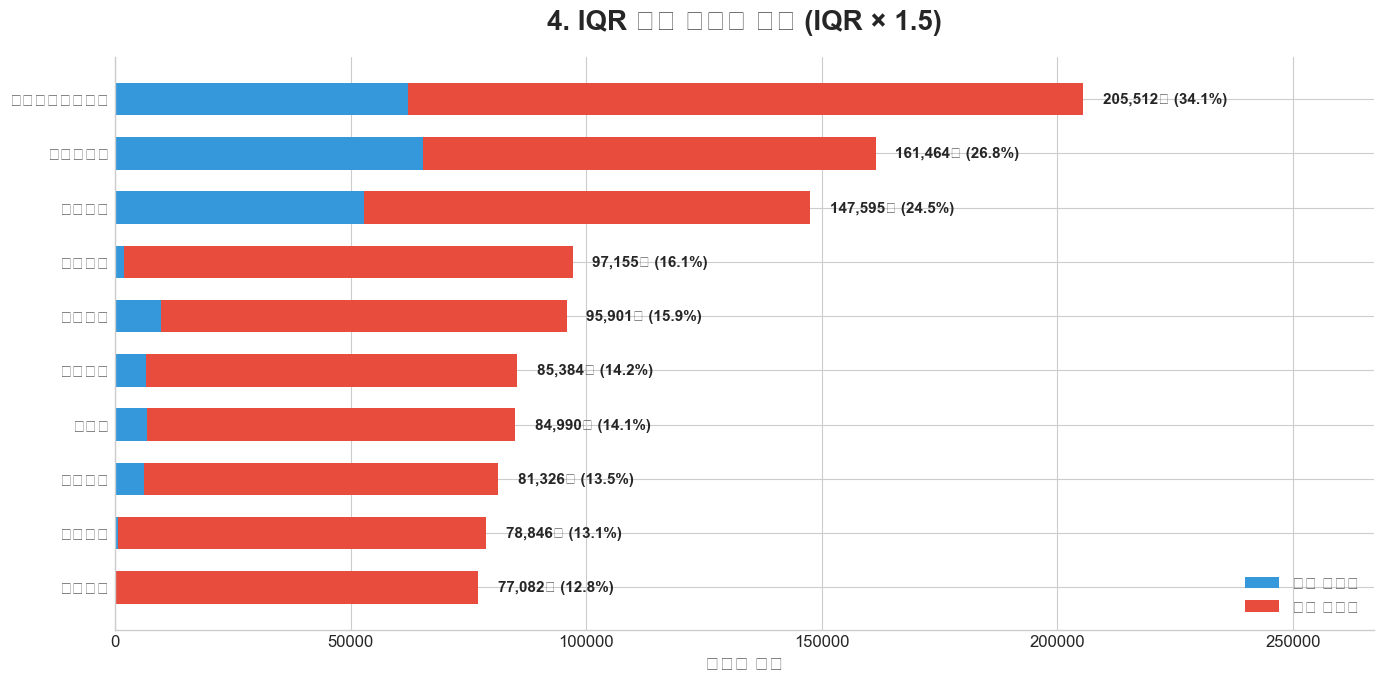

In [12]:
# 이상치 시각화 - 쌓인 막대 그래프 (상한/하한 구분)
if outlier_analysis:
    fig, ax = plt.subplots(figsize=(14, max(6, len(outlier_analysis) * 0.7)))
    
    # 정렬
    sorted_items = sorted(outlier_analysis.items(), key=lambda x: x[1]['total'], reverse=True)
    names = [item[0] for item in sorted_items]
    lower_counts = [item[1]['lower'] for item in sorted_items]
    upper_counts = [item[1]['upper'] for item in sorted_items]
    pcts = [item[1]['pct'] for item in sorted_items]
    
    y_pos = np.arange(len(names))
    
    # 쌓인 막대 그래프
    bars1 = ax.barh(y_pos, lower_counts, height=0.6, label='하한 이상치', color=COLORS['info'])
    bars2 = ax.barh(y_pos, upper_counts, height=0.6, left=lower_counts, label='상한 이상치', color=COLORS['problem'])
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=12)
    ax.invert_yaxis()
    
    # 총 이상치 수 표시
    max_val = max(l + u for l, u in zip(lower_counts, upper_counts))
    for i, (l, u, pct) in enumerate(zip(lower_counts, upper_counts, pcts)):
        total = l + u
        ax.text(total + max_val*0.02, i, f'{total:,}건 ({pct:.1f}%)', 
                va='center', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('이상치 개수', fontsize=14)
    ax.set_title('4. IQR 기준 이상치 현황 (IQR × 1.5)', fontsize=20, fontweight='bold', pad=20)
    ax.legend(loc='lower right', fontsize=12)
    ax.set_xlim(0, max_val * 1.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'eda_4_outliers.png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

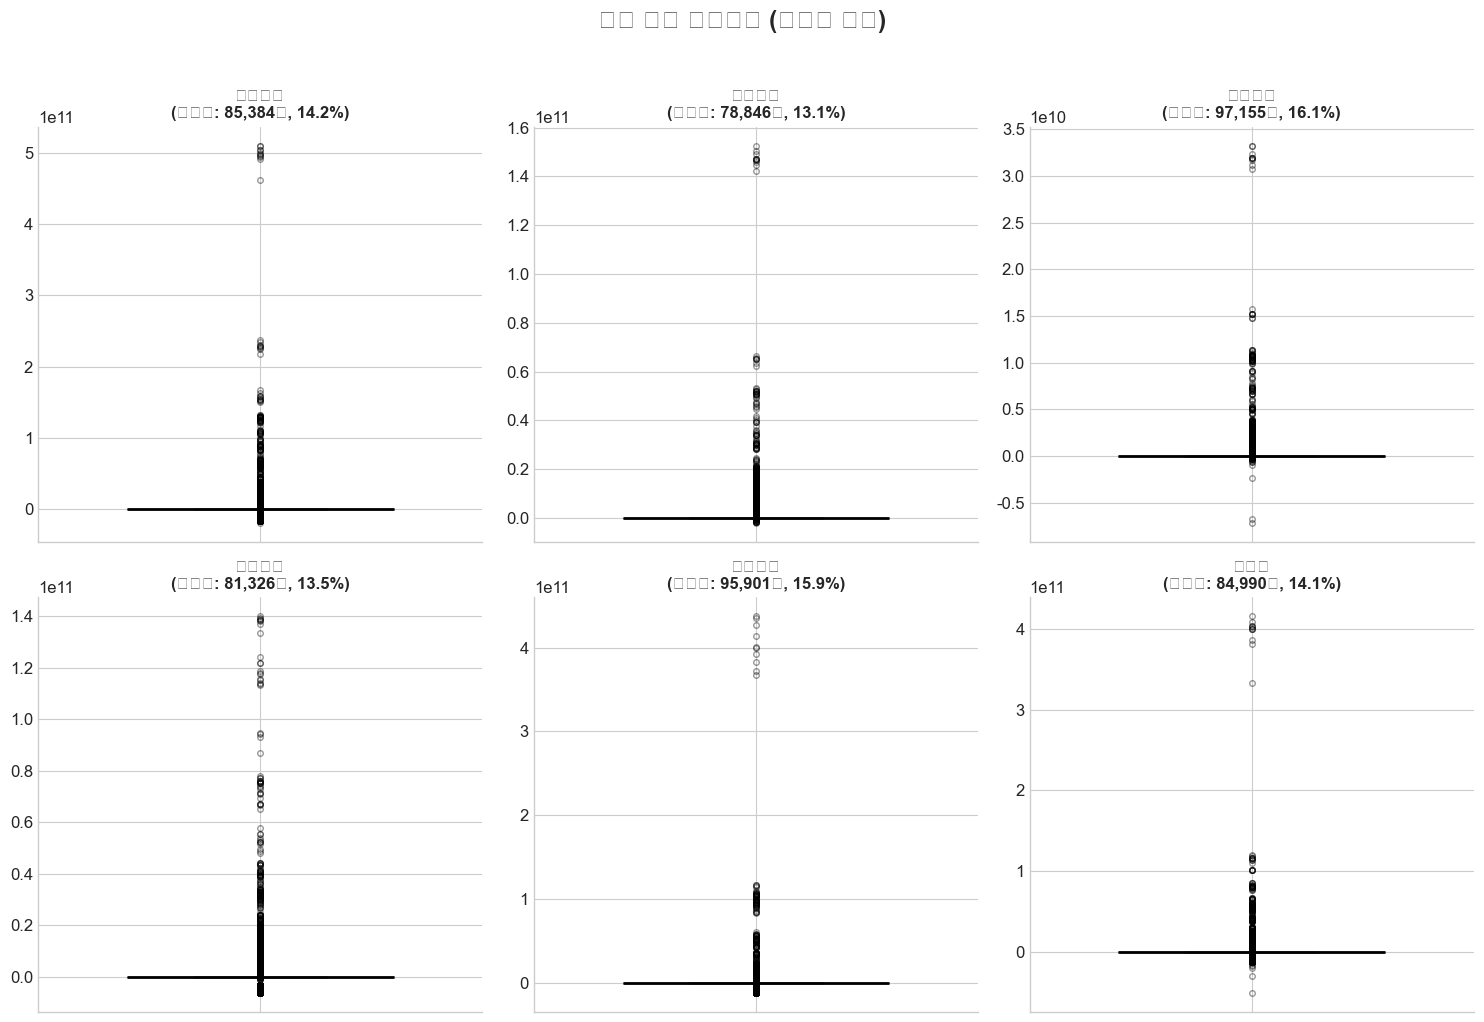

In [13]:
# 박스플롯으로 이상치 분포 시각화 (상위 6개 컬럼)
if outlier_analysis:
    top_items = list(outlier_analysis.items())[:6]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for ax, (name, stats) in zip(axes, top_items):
        col_data = pd.to_numeric(df[name], errors='coerce').dropna()
        
        # 박스플롯
        bp = ax.boxplot(col_data, vert=True, patch_artist=True, widths=0.6)
        
        # 스타일링
        bp['boxes'][0].set_facecolor(COLORS['info'])
        bp['boxes'][0].set_alpha(0.7)
        bp['medians'][0].set_color('black')
        bp['medians'][0].set_linewidth(2)
        
        # 이상치 강조
        for flier in bp['fliers']:
            flier.set(marker='o', color=COLORS['problem'], alpha=0.4, markersize=4)
        
        ax.set_title(f'{name}\n(이상치: {stats["total"]:,}건, {stats["pct"]:.1f}%)', 
                     fontsize=12, fontweight='bold')
        ax.set_xticklabels([''])
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # 빈 서브플롯 숨기기
    for i in range(len(top_items), 6):
        axes[i].axis('off')
    
    plt.suptitle('주요 컬럼 박스플롯 (이상치 분포)', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(output_dir / 'eda_4_boxplots.png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

---
# 5️⃣ 파생컬럼(재무비율) 결측치 분석

재무비율은 Leaf 컬럼을 나누어 계산하므로, 분모가 0인 경우 결측치가 발생합니다.

In [14]:
# 파생컬럼 (재무비율) 결측치 분석
derived_cols = [
    '재무비율_부채비율',
    '재무비율_자기자본비율',
    '재무비율_유동비율',
    '재무비율_차입금의존도',
    '재무비율_매출원가율',
    '재무비율_영업이익율',
    '재무비율_당기순이익율',
    '재무비율_자기자본이익률(ROE)',
    '재무비율_매출채권회전율',
    '재무비율_재고자산회전율',
    '재무비율_총자산회전율',
    '재무비율_총자산순이익률',
]

missing_analysis = {}
total_rows = len(df)

print("=" * 60)
print("❓ 파생컬럼(재무비율) 결측치 분석")
print("=" * 60)
print(f"{'재무비율':<30} {'결측치':>12} {'비율':>10}")
print("-" * 60)

for col in derived_cols:
    if col in df.columns:
        missing_count = df[col].isna().sum()
        # inf 값도 결측으로 처리
        col_data = pd.to_numeric(df[col], errors='coerce')
        inf_count = np.isinf(col_data).sum()
        total_missing = missing_count + inf_count
        missing_pct = total_missing / total_rows * 100
        
        # 짧은 이름 (재무비율_ 제거)
        short_name = col.replace('재무비율_', '')
        
        missing_analysis[short_name] = {
            'col': col,
            'missing': total_missing,
            'missing_pct': missing_pct,
            'valid': total_rows - total_missing
        }
        
        if missing_pct > 0:
            print(f"{short_name:<30} {total_missing:>10,}건 {missing_pct:>9.1f}%")

print("-" * 60)
if missing_analysis:
    avg_missing = np.mean([s['missing_pct'] for s in missing_analysis.values()])
    print(f"{'평균 결측률':<30} {'':>12} {avg_missing:>9.1f}%")
print("=" * 60)

❓ 파생컬럼(재무비율) 결측치 분석
재무비율                                    결측치         비율
------------------------------------------------------------
부채비율                               48,240건       8.0%
자기자본비율                             30,150건       5.0%
유동비율                               72,360건      12.0%
당기순이익율                            376,456건      62.4%
자기자본이익률(ROE)                       90,450건      15.0%
매출채권회전율                            60,300건      10.0%
재고자산회전율                           108,540건      18.0%
총자산순이익률                           386,826건      64.2%
------------------------------------------------------------
평균 결측률                                           16.2%


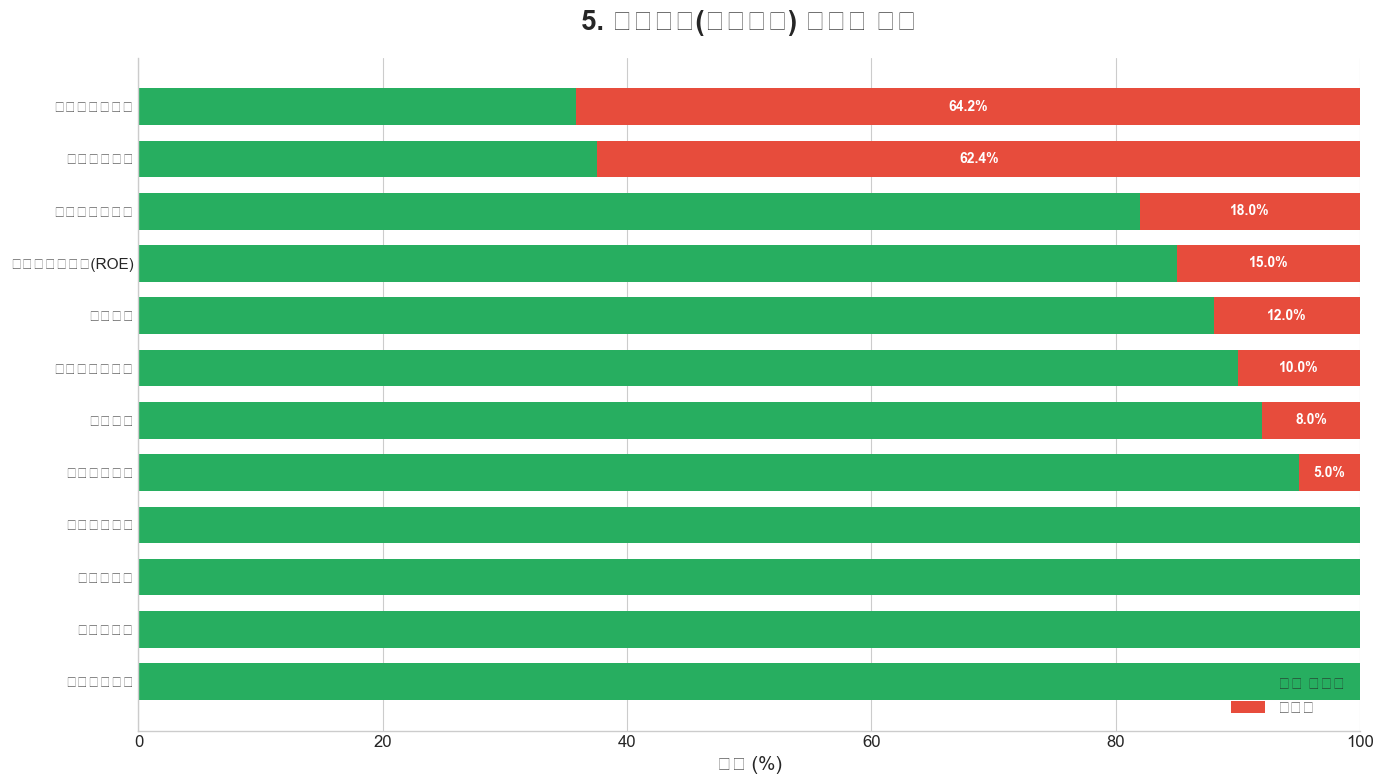

In [15]:
# 파생컬럼 결측치 시각화 - 100% 스택 바 차트
if missing_analysis:
    fig, ax = plt.subplots(figsize=(14, max(8, len(missing_analysis) * 0.6)))
    
    # 정렬 (결측률 높은 순)
    sorted_items = sorted(missing_analysis.items(), key=lambda x: x[1]['missing_pct'], reverse=True)
    names = [item[0] for item in sorted_items]
    missing_pcts = [item[1]['missing_pct'] for item in sorted_items]
    valid_pcts = [100 - pct for pct in missing_pcts]
    
    y_pos = np.arange(len(names))
    
    # 스택 바 차트
    bars1 = ax.barh(y_pos, valid_pcts, height=0.7, label='유효 데이터', color=COLORS['normal'])
    bars2 = ax.barh(y_pos, missing_pcts, height=0.7, left=valid_pcts, label='결측치', color=COLORS['problem'])
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlabel('비율 (%)', fontsize=14)
    ax.set_title('5. 파생컬럼(재무비율) 결측치 현황', fontsize=20, fontweight='bold', pad=20)
    ax.legend(loc='lower right', fontsize=12)
    ax.set_xlim(0, 100)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 결측률 표시
    for i, (name, stats) in enumerate(sorted_items):
        if stats['missing_pct'] > 2:
            ax.text(100 - stats['missing_pct']/2, i, f"{stats['missing_pct']:.1f}%", 
                   va='center', ha='center', fontsize=10, color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'eda_5_missing_derived.png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

---
# 📋 종합 요약: 데이터 품질 대시보드

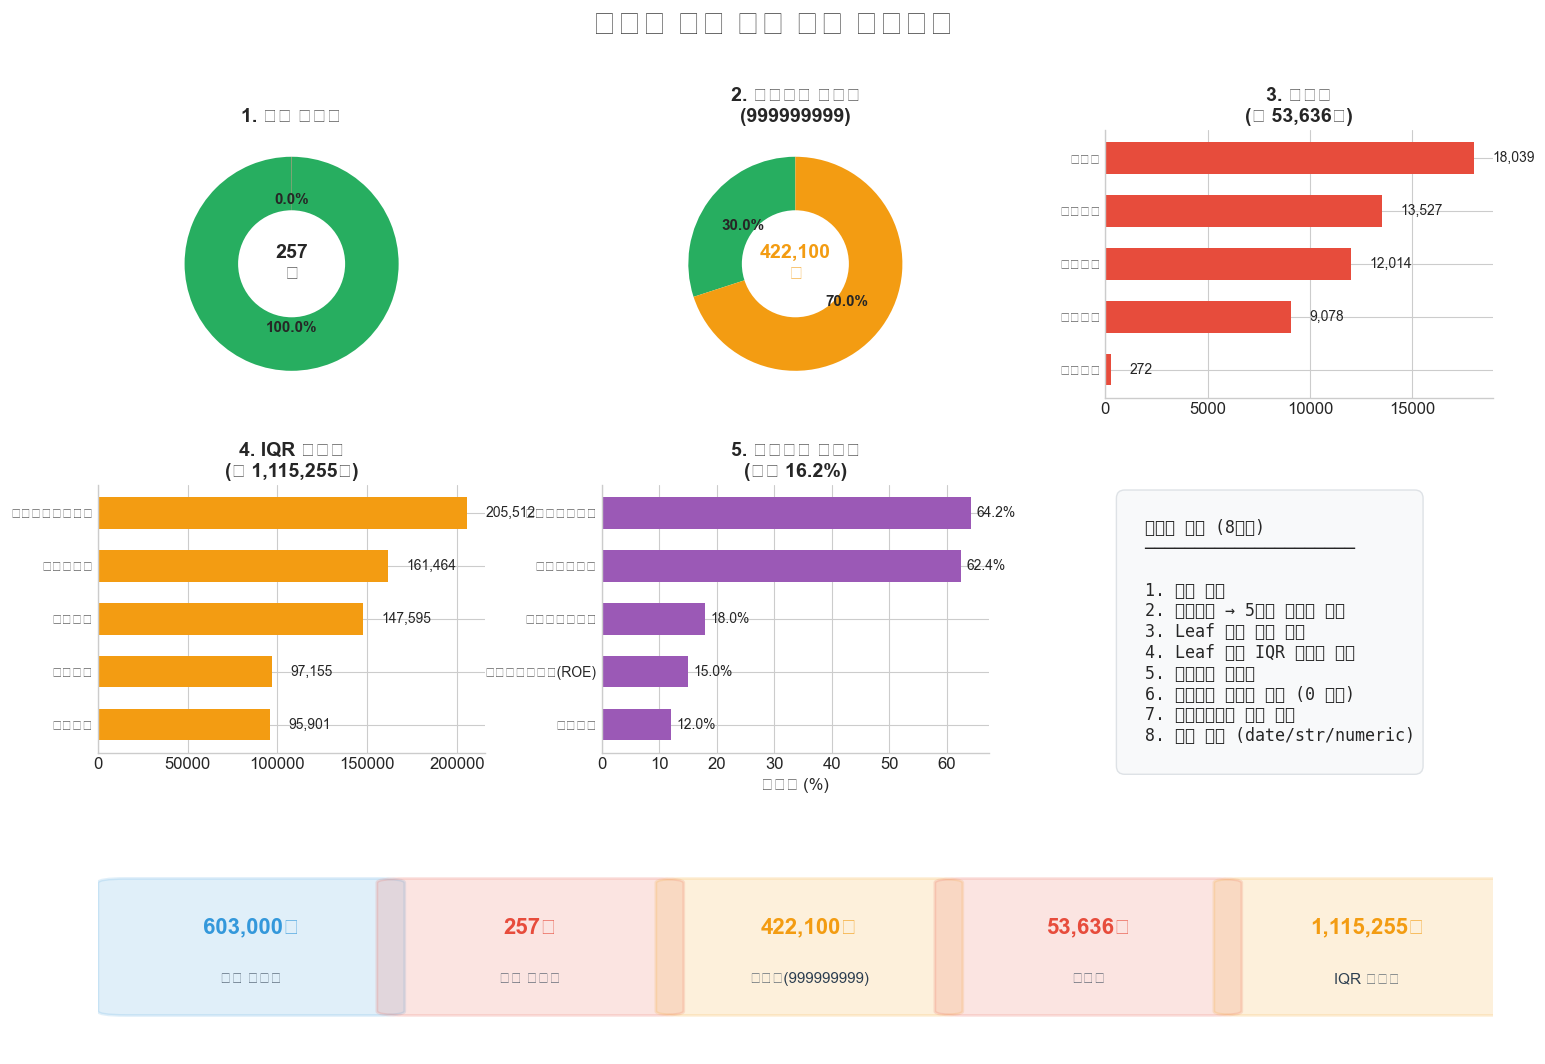

In [16]:
# 종합 요약 대시보드
fig = plt.figure(figsize=(18, 12))

# 그리드 설정
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 0.8], hspace=0.35, wspace=0.3)

# 변수 계산
total_negative = sum(stats['negative'] for stats in negative_analysis.values()) if negative_analysis else 0
total_outliers = sum(stats['total'] for stats in outlier_analysis.values()) if outlier_analysis else 0
avg_missing_pct = np.mean([stats['missing_pct'] for stats in missing_analysis.values()]) if missing_analysis else 0
special_count = days_analysis['special']

# 1. 중복 데이터 (왼쪽 상단)
ax1 = fig.add_subplot(gs[0, 0])
sizes = [unique_rows, max(duplicate_rows, 1)]
colors = [COLORS['normal'], COLORS['problem']]
wedges, _, autotexts = ax1.pie(sizes, colors=colors, autopct='%1.1f%%', startangle=90,
                               textprops={'fontsize': 11, 'fontweight': 'bold'})
centre_circle = plt.Circle((0, 0), 0.5, fc='white')
ax1.add_patch(centre_circle)
ax1.text(0, 0, f'{duplicate_rows:,}\n건', fontsize=14, fontweight='bold', ha='center', va='center')
ax1.set_title(f'1. 중복 데이터', fontsize=14, fontweight='bold')

# 2. 경과일수 특수값 (중앙 상단)
ax2 = fig.add_subplot(gs[0, 1])
sizes = [days_analysis['normal'], days_analysis['special']]
colors = [COLORS['normal'], COLORS['warning']]
wedges, _, _ = ax2.pie(sizes, colors=colors, autopct='%1.1f%%', startangle=90,
                       textprops={'fontsize': 11, 'fontweight': 'bold'})
centre_circle = plt.Circle((0, 0), 0.5, fc='white')
ax2.add_patch(centre_circle)
ax2.text(0, 0, f'{special_count:,}\n건', fontsize=14, fontweight='bold', ha='center', va='center', color=COLORS['warning'])
ax2.set_title(f'2. 경과일수 특수값\n(999999999)', fontsize=14, fontweight='bold')

# 3. 음수값 (오른쪽 상단)
ax3 = fig.add_subplot(gs[0, 2])
if negative_analysis:
    sorted_neg = sorted(negative_analysis.items(), key=lambda x: x[1]['negative'], reverse=True)[:5]
    names = [item[0] for item in sorted_neg]
    counts = [item[1]['negative'] for item in sorted_neg]
    y_pos = np.arange(len(names))
    ax3.barh(y_pos, counts, color=COLORS['problem'], height=0.6)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(names, fontsize=10)
    ax3.invert_yaxis()
    for i, c in enumerate(counts):
        ax3.text(c + max(counts)*0.05, i, f'{c:,}', va='center', fontsize=10)
else:
    ax3.text(0.5, 0.5, '음수값 없음', ha='center', va='center', fontsize=14, color=COLORS['normal'])
ax3.set_title(f'3. 음수값\n(총 {total_negative:,}건)', fontsize=14, fontweight='bold')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# 4. IQR 이상치 (왼쪽 중간)
ax4 = fig.add_subplot(gs[1, 0])
if outlier_analysis:
    sorted_out = sorted(outlier_analysis.items(), key=lambda x: x[1]['total'], reverse=True)[:5]
    names = [item[0] for item in sorted_out]
    counts = [item[1]['total'] for item in sorted_out]
    y_pos = np.arange(len(names))
    ax4.barh(y_pos, counts, color=COLORS['warning'], height=0.6)
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels(names, fontsize=10)
    ax4.invert_yaxis()
    for i, c in enumerate(counts):
        ax4.text(c + max(counts)*0.05, i, f'{c:,}', va='center', fontsize=10)
ax4.set_title(f'4. IQR 이상치\n(총 {total_outliers:,}건)', fontsize=14, fontweight='bold')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# 5. 파생컬럼 결측치 (중앙 중간)
ax5 = fig.add_subplot(gs[1, 1])
if missing_analysis:
    sorted_miss = sorted(missing_analysis.items(), key=lambda x: x[1]['missing_pct'], reverse=True)[:5]
    names = [item[0][:12] + '...' if len(item[0]) > 12 else item[0] for item in sorted_miss]
    pcts = [item[1]['missing_pct'] for item in sorted_miss]
    y_pos = np.arange(len(names))
    ax5.barh(y_pos, pcts, color=COLORS['highlight'], height=0.6)
    ax5.set_yticks(y_pos)
    ax5.set_yticklabels(names, fontsize=10)
    ax5.invert_yaxis()
    ax5.set_xlabel('결측률 (%)')
    for i, p in enumerate(pcts):
        ax5.text(p + 1, i, f'{p:.1f}%', va='center', fontsize=10)
ax5.set_title(f'5. 파생컬럼 결측치\n(평균 {avg_missing_pct:.1f}%)', fontsize=14, fontweight='bold')
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# 6. 클렌징 전략 요약 (오른쪽 중간)
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
strategy_text = """
  클렌징 전략 (8단계)
  ─────────────────────
  
  1. 중복 제거
  2. 경과일수 → 5단계 위험도 변환
  3. Leaf 컬럼 음수 제거
  4. Leaf 컬럼 IQR 이상치 처리
  5. 파생컬럼 재계산
  6. 파생컬럼 이상치 검증 (0 대체)
  7. 주소지시군구 타입 변환
  8. 타입 변환 (date/str/numeric)
"""
ax6.text(0.05, 0.95, strategy_text, fontsize=12, verticalalignment='top',
         fontfamily='monospace', transform=ax6.transAxes,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#dee2e6'))

# 하단: 통계 요약 카드
ax_bottom = fig.add_subplot(gs[2, :])
ax_bottom.axis('off')

# 통계 카드
stats_data = [
    ('전체 데이터', f'{total_rows:,}건', COLORS['info']),
    ('중복 데이터', f'{duplicate_rows:,}건', COLORS['problem']),
    ('특수값(999999999)', f'{special_count:,}건', COLORS['warning']),
    ('음수값', f'{total_negative:,}건', COLORS['problem']),
    ('IQR 이상치', f'{total_outliers:,}건', COLORS['warning']),
]

card_width = 0.18
card_height = 0.6
start_x = 0.02
y = 0.2

for i, (label, value, color) in enumerate(stats_data):
    x = start_x + i * (card_width + 0.02)
    rect = FancyBboxPatch((x, y), card_width, card_height, 
                          boxstyle="round,pad=0.02,rounding_size=0.02",
                          facecolor=color, alpha=0.15, edgecolor=color, linewidth=2,
                          transform=ax_bottom.transAxes)
    ax_bottom.add_patch(rect)
    ax_bottom.text(x + card_width/2, y + card_height*0.65, value, 
                   fontsize=16, fontweight='bold', ha='center', va='center',
                   transform=ax_bottom.transAxes, color=color)
    ax_bottom.text(x + card_width/2, y + card_height*0.25, label, 
                   fontsize=11, ha='center', va='center',
                   transform=ax_bottom.transAxes, color=COLORS['dark'])

plt.suptitle('데이터 품질 문제 종합 대시보드', fontsize=24, fontweight='bold', y=0.98)
plt.savefig(output_dir / 'eda_summary_dashboard.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [17]:
print("\n" + "=" * 70)
print("📊 EDA 시각화 완료!")
print("=" * 70)
print("\n생성된 이미지 파일:")
print("-" * 70)
for f in sorted(output_dir.glob('*.png')):
    print(f"  📁 {f.name}")
print("-" * 70)
print(f"\n📂 저장 위치: {output_dir.absolute()}")
print("\n💡 참고: 이 노트북은 발표용으로 시뮬레이션된 품질 문제를 사용합니다.")
print("    실제 원본 데이터에서도 유사한 문제가 발생할 수 있습니다.")
print("=" * 70)


📊 EDA 시각화 완료!

생성된 이미지 파일:
----------------------------------------------------------------------
  📁 eda_1_duplicates.png
  📁 eda_2_days_distribution.png
  📁 eda_2_special_values.png
  📁 eda_3_negative_values.png
  📁 eda_4_boxplots.png
  📁 eda_4_outliers.png
  📁 eda_5_missing_derived.png
  📁 eda_summary_dashboard.png
----------------------------------------------------------------------

📂 저장 위치: /Users/kje/coding/project/fintech-cb-pipeline/notebooks/../docs/eda_images

💡 참고: 이 노트북은 발표용으로 시뮬레이션된 품질 문제를 사용합니다.
    실제 원본 데이터에서도 유사한 문제가 발생할 수 있습니다.
